# Multiple Sticker Model
Based off Indei & Takimoto (2010), we're gonna implement what they did and compare it to our model. The association and dissociation rates we will have to calculate ourselves from the simulations, so we can start with getting the same plots as they generate.

We make the same assumption that the association and dissociation rates of all the stickers is the same, $\alpha, \beta$

## $\mathbf{K}(l)$ recursively generating $\mathbf W(N_a)$

The relation to generate the transition rate matrix $\mathbf W$ recursively is 
$$
\mathbf K (1) \equiv \begin{pmatrix}
1 & \beta_{0} \\
\alpha_{0} & 1
\end{pmatrix}
$$
$$
\mathbf{K}(l)=\begin{pmatrix}
\mathbf{K}(l-1) & \beta_{(l-1)M}\mathbf{I}_{2^{l-1}} \\
\alpha_{(l-1)M}\mathbf{I}_{2^{l-1}} & \mathbf{K}(l-1)
\end{pmatrix}
$$
$$
W_{s^\prime,s}(N_{a}) = \begin{cases}
K_{s^\prime,s}(N_{a}) & \text{(if $s^\prime \neq s$)}\\
-\sum_{s^{\prime\prime}(\neq s)=0}^{s_{\text{max}}}K_{s^{\prime\prime},s}(N_{a}) & \text{(if $s^\prime = s$)}
\end{cases}
$$

## Generating $\mathbf{K}(l)$

In [2]:
import numpy as np

def recursive_K(l, α, β):
    if l == 1:
        return np.array([[1, β],[α, 1]])
    else:
        tl = recursive_K(l-1, α, β)
        tr = β * np.identity(2 ** (l-1))
        bl = α * np.identity(2 ** (l-1))
        br = recursive_K(l-1, α, β)
        return np.block([[tl, tr],
                          [bl, br]])

def recursive_K_list(l, α_list, β_list):
    if l == 1:
        return np.array([[1, β_list[0]],[α_list[0], 1]])
    else:
        tl = recursive_K_list(l-1, α_list[:-1], β_list[:-1])
        tr = β_list[l-1] * np.identity(2 ** (l-1))
        bl = α_list[l-1] * np.identity(2 ** (l-1))
        br = recursive_K_list(l-1, α_list[:-1], β_list[:-1])
        return np.block([[tl, tr],
                          [bl, br]])


In [3]:
l = 3
α = 2
β = 3
K_l = recursive_K(l, α, β)
# np.identity(int(2 ** (l-1)))
print(K_l)
np.sum(K_l, axis=0)

[[1. 3. 3. 0. 3. 0. 0. 0.]
 [2. 1. 0. 3. 0. 3. 0. 0.]
 [2. 0. 1. 3. 0. 0. 3. 0.]
 [0. 2. 2. 1. 0. 0. 0. 3.]
 [2. 0. 0. 0. 1. 3. 3. 0.]
 [0. 2. 0. 0. 2. 1. 0. 3.]
 [0. 0. 2. 0. 2. 0. 1. 3.]
 [0. 0. 0. 2. 0. 2. 2. 1.]]


array([ 7.,  8.,  8.,  9.,  8.,  9.,  9., 10.])

In [4]:
l = 3
α = np.arange(1, l+1) * 2
β = np.arange(1, l+1) * 3
K_l = recursive_K_list(l, α, β)
print(K_l)

[[1. 3. 6. 0. 9. 0. 0. 0.]
 [2. 1. 0. 6. 0. 9. 0. 0.]
 [4. 0. 1. 3. 0. 0. 9. 0.]
 [0. 4. 2. 1. 0. 0. 0. 9.]
 [6. 0. 0. 0. 1. 3. 6. 0.]
 [0. 6. 0. 0. 2. 1. 0. 6.]
 [0. 0. 6. 0. 4. 0. 1. 3.]
 [0. 0. 0. 6. 0. 4. 2. 1.]]


## Generating $\mathbf W(N_a)$

In [39]:
# N_a is the total number of stickers on a chain
def generate_W(N_a, α, β):
    K_N_a = recursive_K(N_a, α, β)
    K_upper = np.triu(K_N_a, 1)
    K_lower = np.tril(K_N_a, -1)
    
    W_diagonal = np.diagflat(-np.sum(K_N_a, axis=0)+1)

    return K_upper + K_lower + W_diagonal

def generate_W_lists(N_a, α_list, β_list):
    if len(α_list) != len(β_list) or len(α_list) != N_a:
        raise ValueError("Incorrect number of association/dissociation parameters.")
    K_N_a = recursive_K_list(N_a, α_list, β_list)
    K_upper = np.triu(K_N_a, 1)
    K_lower = np.tril(K_N_a, -1)
    
    W_diagonal = np.diagflat(-np.sum(K_N_a, axis=0)+1)

    return K_upper + K_lower + W_diagonal


In [40]:
l = 3
α = 2
β = 3

# from equation 14
test_W_3 = np.array([[-6, β, β, 0, β, 0, 0, 0],
                    [α, -7, 0, β, 0, β, 0, 0],
                    [α, 0, -7, β, 0, 0, β, 0],
                    [0, α, α, -8, 0, 0, 0, β],
                    [α, 0, 0, 0, -7, β, β, 0],
                    [0, α, 0, 0, α, -8, 0, β],
                    [0, 0, α, 0, α, 0, -8, β],
                    [0, 0, 0, α, 0, α, α, -9]])

W_3 = generate_W(3, 2, 3)
W_3_list = generate_W_lists(3, [2, 2, 2], [3, 3, 3])

# test if all entries are the same
print(np.array_equal(test_W_3, W_3))
print(np.array_equal(test_W_3, W_3_list))

True
True


In [41]:
generate_W(1, 2, 3)

array([[-2,  3],
       [ 2, -3]])

# Connectivity matrix $\mathbf B^s$

This matrix determines the equations of motion for an association state $s$, so we should start by decoding $s$ to be an array of association states ($n^s_i = 1$ means $i\text{th}$ bead in association state $s$ is associated, $n^s_i = 0$ is free).

The definition in the paper is a little confusing -- when first defined, $n^s_i$ is implied to be from $i=1,\dots, N_b -1$. However, in the same paragraph, it's stated that for $s=s_\text{max}, n_i^{s_\text{max}}=1$ for all $i$, which is only true for $M=1$ or if $i=1, \dots, N_a$. The latter is likely the error, as there are more usages of the first definition.

This affects extracting $n_i^s$ as we'll pad the gaps between stickers with $M-1$ entries of $0$. 

In [7]:
def extract_n_s(s, M, N_b):
    N_a = (N_b - 1) // M + 1
    if N_a < M:
        raise ValueError("N_a must be greater than or equal to M.")
    
    n_s = np.zeros(M * (N_a-1) + 1, dtype=int)

    index = 0
    while True:
        n_s[index] = s & 1
        s = s >> 1
        if s == 0:
            break
        if index >= M * (N_a-1):
            raise ValueError(f"s is too large to fit in the specified number of stickers and spacing, s^max = {2 ** N_a - 1}.")
        index += M
    return n_s

s = 15
N_b = 13
M = 3
print(extract_n_s(s, M, N_b))


[1 0 0 1 0 0 1 0 0 1 0 0 0]


The resulting $\mathbf B^s$ matrix should look like
$$
B_{i,j}^s \equiv a_i^s \delta_{i, j+1} + b_i^s \delta_{i, j} + c_i^s \delta_{i, j-1}
$$
so we have a tridiagonal matrix. These tridiagonal elements are 
$$
(a_i^s, b_i^s, c_i^s) = 
\begin{cases}
(0,0,0) & \text{(if $(n_{i-1}^s,n_i^s)=(1,1)$)} \\
(-1,1,0) & \text{(if $(n_{i-1}^s,n_i^s)=(0,1)$)} \\
(0,1,-1) & \text{(if $(n_{i-1}^s,n_i^s)=(1,0)$)} \\
(-1,2,-1) & \text{(if $(n_{i-1}^s,n_i^s)=(0,0)$)}
\end{cases}
$$
Note that the first case is not possible unless $M=1$ and we have only sticker beads. 

We can set each diagonal individually and compose them together.

In [64]:
def generate_B(N_b, s, M):
    n_s = extract_n_s(s, M)
    B = np.zeros((N_b-1, N_b-1))

    for i, pair in enumerate(zip(n_s[:-1], n_s[1:])):
        if pair == (0, 0):
            # (0, 0, 0)
            if i == 0:
                B[i, i] = 0
                B[i, i+1] = 0
            elif i == N_b - 2:
                B[i, i-1] = 0
                B[i, i] = 0
            else:
                B[i, i-1] = 0
                B[i, i] = 0
                B[i, i+1] = 0
        elif pair == (0, 1):
            # (-1, 1, 0)
            if i == 0:
                B[i, i] = -1
                B[i, i+1] = 0
            elif i == N_b - 2:
                B[i, i-1] = -1
                B[i, i] = 1
            else:
                B[i, i-1] = -1
                B[i, i] = 1
                B[i, i+1] = 0
        elif pair == (1, 0):
            # (0, 1, -1)
            if i == 0:
                B[i, i] = 1
                B[i, i+1] = -1
            elif i == N_b - 2:
                B[i, i-1] = 0
                B[i, i] = 1
            else:
                B[i, i-1] = 0
                B[i, i] = 1
                B[i, i+1] = -1
        elif pair == (1, 1):
            # (-1, 2, -1)
            if i == 0:
                B[i, i] = 2
                B[i, i+1] = -1
            elif i == N_b - 2:
                B[i, i-1] = -1
                B[i, i] = 2
            else:
                B[i, i-1] = -1
                B[i, i] = 2
                B[i, i+1] = -1
    return B

Absolutely awful stuff, let's do this better.

In [65]:
# Note: negating 0 gives -1, we have to add some int() typecasts
def generate_B(s, M, N_b):
    if (N_b-1) % M != 0:
        raise ValueError("N_b-1 must be divisible by M.")
    n_s = extract_n_s(s, M, N_b)
    B = np.zeros((N_b-1, N_b-1))

    for i, pair in enumerate(zip(n_s[:-1], n_s[1:])):
        if i != 0: # a_i
            B[i, i-1] = -1 * int(pair[0]==0)
        if i != N_b - 2: # c_i
            B[i, i+1] = -1 * int(pair[1]==0)
        # b_i
        B[i, i] = (int(pair[0]==0) or int(pair[1]==0)) + (int(pair[0]==0) and int(pair[1]==0))

    return B

Much better, this takes care of each diagonal using some boolean logic, each pair encodes the element at index $i+1$ and $i+2$.

In [69]:
s = 0b1010
M = 1
N_b = 4

print(extract_n_s(s, M, N_b))
print(generate_B(s, M, N_b))

[0 1 0 1]
[[ 1.  0.  0.]
 [ 0.  1. -1.]
 [ 0. -1.  1.]]


# Solving equations for $h_{k,l}^s, g_{k,l}^s$
We need to solve for coefficients $h_{k,l}^s, g_{k,l}^s$ governed by equation 25a
$$
- \omega h_{k,l}^s + \frac{k_b}{\zeta} \sum_{j=1}^{N_b-1}(B_{k,j}^sg_{j,l}^s + B_{l,j}^sg_{k,j}^s) = \sum_{s^\prime=0}^{s_\text{max}}W_{s^\prime, s} g_{k,l}^{s^\prime}
$$
and 25b
$$
\omega g_{k,l}^s-\omega \delta_{k,l} + \frac{k_b}{\zeta}\sum_{j=1}^{N_b-1}(B_{k,j}^sh_{j,l}^s+B_{l,j}^sh_{k,j}^s)=\sum_{s^\prime=0}^{s_\text{max}}W_{s^\prime,s}h_{k,l}^{s^\prime}
$$

which allows us to solve for the shear dynamic moduli,
$$
G^\prime(\omega) = k_BT \sum_{s=0}^{s_\text{max}}\sum_{k=1}^{N_b-1}\nu^sg_{k,k}^s(\omega)
$$
$$
G^{\prime\prime}(\omega) = k_BT \sum_{s=0}^{s_\text{max}}\sum_{k=1}^{N_b-1}\nu^sh_{k,k}^s(\omega)
$$

To make terms dimensionless, the following replacements are made:
$$
t \to \beta t\\ \omega \to \frac \omega \beta\\ \alpha \to \frac \alpha \omega\\ \zeta \to \frac{\zeta \beta a_\text K^2}{3k_BT} \equiv \tilde{\zeta}
$$
such that $1/\beta$ is a unit of time.

To encode the equations, we vectorize $\mathbf g$ and $\mathbf h$.

In [11]:
import numpy as np

# physical chain parameters
N_b = 31
N_a = 7
M = 5
s_max = 2**N_a - 1

# calculation parameters
omega = 1
k_b = 1
zeta = 1

vectorize_length = (N_b - 1) * (N_b - 1) * (s_max + 1)

# vectorize h, k --> goes from (N_b - 1) x (N_b - 1) x (s_max + 1) to (N_b - 1) * (N_b - 1) * (s_max + 1) x 1
g = np.zeros(vectorize_length)
h = np.zeros(vectorize_length)

x = np.concatenate((g,h))
# grouped like l, then k, then s -> N_b - 1 elements along axis l, then N_b - 1 of those for axis k, then s_max + 1 of those for axis s. 

"""
Convert indices s, k, l to index of vectorized g. 
note that k,l indices are 1-based, hence (index-1), but s is 0-based

In the vector x (concatenate g and h) g comes first.

Args:
    - s: s index, in [1, s_{max} + 1]
    - k: k index, in [1, N_b - 1]
    - l: l index, in [1, N_b - 1]
    - s_max: maximum association state
    - N_b: number of beads

Returns: 
    - index along vectorized g vector
"""
def g_index(s, k, l, s_max, N_b):
    return s*(N_b-1)**2 + (k-1)*(N_b-1) + (l-1)

"""
Convert indices s, k, l to index of vectorized h. 
note that k,l indices are 1-based, hence (index-1), but s is 0-based

In the vector x (concatenate g and h) h comes second, offset by (N_b-1) * (N_b-1) * (s_max+1)

Args:
    - s: s index, in [1, s_{max} + 1]
    - k: k index, in [1, N_b - 1]
    - l: l index, in [1, N_b - 1]
    - s_max: maximum association state
    - N_b: number of beads

Returns: 
    - index along vectorized g vector
"""
def h_index(s, k, l, s_max, N_b):
    # print((s_max+1))
    # print((N_b-1))
    # print((s_max+1)*(N_b-1)**2 + s*(N_b-1)**2 + (k-1)*(N_b-1) + (l-1))
    return (s_max+1)*(N_b-1)**2 + s*(N_b-1)**2 + (k-1)*(N_b-1) + (l-1)


We can now generate the linear equation according to what equations 25a and 25b say. The final result should be a linear equation
$$
\mathbf A\vec x = \vec b
$$
where
$$
\mathbf A = \begin{pmatrix}\mathbf A_a \\ \mathbf  A_b\end{pmatrix}, \vec x = \begin{pmatrix}\operatorname{vec}(\mathbf g)  \\ \operatorname{vec}(\mathbf h)\end{pmatrix}, \vec b = \begin{pmatrix} \vec 0 \\ \omega \delta_{k,l}\end{pmatrix}
$$
To be clear, the sizes of these matrices are (assuming real entries): 
$$
\mathbf A \in \mathbb R^{(2 l_{vec}) \times (2 l_{vec})} \\
\mathbf A_a, \mathbf A_b \in \mathbb R^{l_{vec} \times 2l_{vec}} \\
\vec x \in \mathbb R^{2l_{vec}}\\
\vec b \in \mathbb R^{2l_{vec}}\\
l_{vec}=(N_b-1)(N_b-1)(s_\text{max}+1)
$$
The matrices $\mathbf A_a, \mathbf A_b$ encode equations 25, 
$$
(\mathbf{A}_a\vec x)_{s,k,l} =  -\omega h_{k,l}^s + \frac{k_b}{\zeta} \sum_{j=1}^{N_b-1}(B_{k,j}^sg_{j,l}^s + B_{l,j}^sg_{k,j}^s) - \sum_{s^\prime=0}^{s_\text{max}}W_{s^\prime, s} g_{k,l}^{s^\prime}
$$
and
$$
(\mathbf{A}_b\vec x)_{s,k,l} = \omega g_{k,l}^s + \frac{k_b}{\zeta}\sum_{j=1}^{N_b-1}(B_{k,j}^sh_{j,l}^s+B_{l,j}^sh_{k,j}^s)-\sum_{s^\prime=0}^{s_\text{max}}W_{s^\prime,s}h_{k,l}^{s^\prime}
$$
respectively. I'm not entirely sure what I'm doing with the notation here but it makes sense to me. Each row encodes one of these equations, 

In [ ]:
from scipy.sparse import lil_matrix, csr_matrix, csc_matrix, coo_matrix
from time import time
"""
Construct coupling matrix A and constant RHS b such that we can solve an equation Ax = b to get values of g, h
In this form, x is stacked vectorized g and h. Each row of A encodes an equation.
A encodes equation 25a in the first vectorize_length rows, and 25b in the second vectorize_length rows.

We additionally need B^s_{k,l} and W_{s', s} matrices. W isn't a problem, but B needs to be composed into a 
tensor for each valid value of s.

Generating with COO sparse matrix is the fastest out of what I tested.

Args:
    - omega: omega value to calculate shear dynamic moduli -- each omega value gives us one value of G' and G'' each
    - B: (s_max + 1) x (N_b - 1) x (N_b - 1) bead connectivity matrix
    - W: (s_max + 1) x (s_max + 1) association state transition matrix
    - k_b: spring constant along backbone beads
    - zeta: friction constant from Langevin equation (also dimensionless friction constant, they are interchangeable)
    - N_k: number of Kuhn steps in one chain, used if dimensionless (i.e. if k_b is none, replaces k_b)
    - N_b: number of beads in one chain
    - M: spacing of stickers
    - N_a: number of stickers in one chain (if None, is calculated)
    - s_max: maximum association state (if None, is calculated)
    - pbar: optional tqdm progress bar to update during construction (single global bar)
Returns:
    - A: matrix A encoding equations 25a and 25b to be applied to vectorized g and h.
    - b: RHS constants from equations 25a and 25b
"""
def construct_Ab(omega, B, W, k_b=None, zeta=1e-5, N_k=128, N_b=15, M=2, N_a=8, s_max=None, pbar=None):
    start = time()

    if N_a == None:
        N_a = (N_b - 1) // M + 1
    
    if s_max == None:
        s_max = 2**N_a - 1
    
    vectorize_length = (s_max + 1) * (N_b - 1) * (N_b - 1)

    # A = coo_matrix((2 * vectorize_length, 2 * vectorize_length)) # sized to be the same as x
    # b = coo_matrix((2 * vectorize_length, 1))

    # print("Shape A:", np.shape(A))
    # print("Shape b:", np.shape(b))
    # print("Shape B:", np.shape(B))
    # print("Shape W:", np.shape(W))

    if k_b == None:
        k_b_zeta = 1/(zeta * N_k)
        print(f"Using dimensionless k_b = 1/N_k = {1/N_k}, zeta = {zeta}, so k_b/zeta = {k_b_zeta}")
    else:
        k_b_zeta = k_b/zeta
        print(f"Using k_b = {k_b}, zeta = {zeta}, so k_b/zeta = {k_b_zeta}")

    rows = []
    cols = []
    data = []

    b_rows = []
    b_cols = []
    b_data = []
    

    for s in range(s_max+1):
        for k in range (1, N_b):
            for l in range (1, N_b):
                # print(f"{s} {k} {l}")
                # ---------------------------------------------
                # eqn. 25a
                # ---------------------------------------------
                row = g_index(s, k, l, s_max, N_b)

                rows.append(row)
                cols.append(h_index(s, k, l, s_max, N_b))
                data.append(-omega) # -\omega h_{k,l}^s
                # A[row, h_index(s, k, l, s_max, N_b)] += -omega # -\omega h_{k,l}^s
                
                # + \frac{k_b}{\zeta} \sum_{j=1}^{N_b-1}(B_{k,j}^sg_{j,l}^s + B_{l,j}^sg_{k,j}^s)
                for j in range(1, N_b): # j from 1 to N_b - 1
                    rows.append(row)
                    cols.append(g_index(s, j, l, s_max, N_b))
                    data.append(k_b_zeta * B[s, k-1, j-1])
                    rows.append(row)
                    cols.append(g_index(s, k, j, s_max, N_b))
                    data.append(k_b_zeta * B[s, l-1, j-1])
                    # A[row, g_index(s, j, l, s_max, N_b)] += k_b_zeta * B[s, k-1, j-1] # again, k and l are 1-based indices
                    # A[row, g_index(s, k, j, s_max, N_b)] += k_b_zeta * B[s, l-1, j-1]

                # - \sum_{s^\prime=0}^{s_\text{max}}W_{s^\prime, s} g_{k,l}^{s^\prime}
                for s_i in range(s_max + 1): # s_i from 0 to s_max
                    rows.append(row)
                    cols.append(g_index(s_i, k, l, s_max, N_b))
                    data.append(-W[s_i, s])
                    # A[row, g_index(s_i, k, l, s_max, N_b)] += -W[s_i, s] # but s is 0-based index

                # for 25a, b = 0
                # update global progress bar (one unit per (s,k,l) processed for eqn 25a)
                if pbar is not None:
                    pbar.update(1)
    
    # restart loop -- we want to be writing second half of A AFTER first half to take advantage of lil_matrix
    for s in range(s_max + 1):
        for k in range (1, N_b):
            for l in range (1, N_b):
                # ---------------------------------------------
                # eqn. 25b
                # ---------------------------------------------
                row = h_index(s, k, l, s_max, N_b)

                rows.append(row)
                cols.append(g_index(s, k, l, s_max, N_b))
                data.append(omega) # \omega g_{k,l}^s
                # A[row, g_index(s, k, l, s_max, N_b)] += omega # \omega g_{k,l}^s
                
                # + \frac{k_b}{\zeta}\sum_{j=1}^{N_b-1}(B_{k,j}^sh_{j,l}^s+B_{l,j}^sh_{k,j}^s)
                for j in range(1, N_b):
                    rows.append(row)
                    cols.append(h_index(s, j, l, s_max, N_b))
                    data.append(k_b_zeta * B[s, k-1, j-1])
                    rows.append(row)
                    cols.append(h_index(s, k, j, s_max, N_b))
                    data.append(k_b_zeta * B[s, l-1, j-1])
                    # A[row, h_index(s, j, l, s_max, N_b)] += k_b_zeta * B[s, k-1, j-1]
                    # A[row, h_index(s, k, j, s_max, N_b)] += k_b_zeta * B[s, l-1, j-1]

                # - \sum_{s^\prime=0}^{s_\text{max}}W_{s^\prime, s} h_{k,l}^{s^\prime}
                for s_i in range(s_max + 1): # s_i from 0 to s_max
                    rows.append(row)
                    cols.append(h_index(s_i, k, l, s_max, N_b))
                    data.append(-W[s_i, s])
                    # A[row, h_index(s_i, k, l, s_max, N_b)] += -W[s_i, s]

                # for 25b, b = \omega \delta_{k,l}
                if k == l:
                    b_rows.append(h_index(s, k, l, s_max, N_b))
                    b_cols.append(0)
                    b_data.append(omega)
                    # b[h_index(s, k, l, s_max, N_b),0] += omega

                # update global progress bar (one unit per (s,k,l) processed for eqn 25b)
                if pbar is not None:
                    pbar.update(1)

    end = time()
    print(f"Finished constructing entries in {end - start:.2f} seconds")
    start = end

    A = coo_matrix((data, (rows, cols)), (2 * vectorize_length, 2 * vectorize_length)) # sized to be the same as x
    b = coo_matrix((b_data, (b_rows, b_cols)),(2 * vectorize_length, 1))

    A.eliminate_zeros()
    b.eliminate_zeros()

    A.sum_duplicates()
    b.sum_duplicates()

    end = time()
    print(f"Finished summing duplicates/eliminating zeros in {end - start:.2f} seconds")
    start = end

    return A.tocsc(), b.tocsc()



As we need tensors of $\mathbf B$, with one $\mathbf B$ matrix (slice) per value of $s$,

In [43]:
def B_tensor(M=2, N_b=15):
    N_a = (N_b - 1) // M + 1
    s_max = 2**N_a - 1
    B = np.zeros((s_max + 1, N_b-1, N_b-1))
    for s in range(2**N_a - 1):
        B_mat = generate_B(s=s, M=M, N_b=N_b)
        B[s] = B_mat
    return B
# B_tensor()


In [44]:
from scipy.sparse.linalg import spsolve
import scikits.umfpack

B = B_tensor()
W = generate_W(8, 1, 1) # alpha is 1, beta is always 1 (in units of 1/beta)

start = time()
A, b = construct_Ab(1, B, W, N_k=128)
print(f"Non-zero entries of A: {A.nnz}")
print(f"Matrix constructed in {time() - start:.2f} seconds.")

start = time()
# x = spsolve(A, b, use_umfpack=True)
print(f"Solved with direct solver in {time() - start:.2f} seconds.")

del A, b


Finished constructing entries in 3.86 seconds
Finished summing duplicates/eliminating zeros in 3.09 seconds
Non-zero entries of A: 1289456
Matrix constructed in 7.29 seconds.
Solved with direct solver in 0.00 seconds.


In [45]:
# Exception("Test exception to check error handling.")

In [46]:
def count_associated(s, M=2, N_b=15):
    return np.sum(extract_n_s(s, M, N_b))

# n_c is density of chains
def nu_s(s, alpha, beta, M, N_b, n_c=1):
    N_a = (N_b - 1) // M + 1
    N_s = count_associated(s, M, N_b)
    return alpha**N_s * beta**(N_a - N_s) / (alpha + beta)**N_a * n_c
    

def dynamic_shear_moduli(x, alpha, beta, s_max, M, N_b, k_B=1, T=1, n_c=1):
    length = len(x)//2
    print(length)
    g = np.reshape(x[:length], (s_max+1, N_b-1, N_b-1))
    h = np.reshape(x[length:], (s_max+1, N_b-1, N_b-1))

    G_p = 0
    G_pp = 0 
    for s in range(s_max+1):
        for k in range(N_b-1):
            G_p += k_B*T* nu_s(s, alpha, beta, M, N_b, n_c)*g[s, k, k]
            G_pp += k_B*T* nu_s(s, alpha, beta, M, N_b, n_c)*h[s, k, k]

    return G_p, G_pp


In [47]:
# G_p, G_pp = dynamic_shear_moduli(x, 1, 1, 2**8-1, 2, 15)
# print(f"G_p: {G_p:.4f}, G_pp: {G_pp:.4f}")

In [ ]:
from tqdm.notebook import tqdm


def check_g_h_solution(x, b, omega, N_b=15, s_max=2**8-1, M=2):
    pbar = tqdm(total=2 * (s_max + 1) * (N_b - 1) * (N_b - 1), desc="Checking equations")
    for s in range(s_max + 1):
        for k in range (1, N_b):
            for l in range (1, N_b):
                # ---------------------------------------------
                # eqn. 25b
                # ---------------------------------------------
                row = h_index(s, k, l, s_max, N_b)

                lhs = A[row,:].dot(x)
                rhs = b[row,0]
                if not np.isclose(lhs, rhs):
                    print(f"Equation not satisfied for s={s}, k={k}, l={l}. LHS: {lhs}, RHS: {rhs}")
                    return False
                pbar.update(1)
                row = g_index(s, k, l, s_max, N_b)
                lhs = A[row,:].dot(x)
                rhs = b[row,0]
                if not np.isclose(lhs, rhs):
                    print(f"Equation not satisfied for s={s}, k={k}, l={l}. LHS: {lhs}, RHS: {rhs}")
                    return False
                pbar.update(1)
    pbar.close()
    print("All equations satisfied.")
    return True

In [ ]:
check_g_h_solution(x, b, omega=1)

In [93]:
from tqdm.notebook import tqdm


def check_g_h_solution(x, b, omega, N_b=15, s_max=2**8-1, M=2):
    pbar = tqdm(total=2 * (s_max + 1) * (N_b - 1) * (N_b - 1), desc="Checking equations")
    for s in range(s_max + 1):
        for k in range (1, N_b):
            for l in range (1, N_b):
                # ---------------------------------------------
                # eqn. 25a
                # ---------------------------------------------
                lhs = -omega * x[h_index(s, k, l, s_max, N_b)]
                for j in range(1, N_b):
                    lhs += 1 / (128 * 1e-5) * B[s, k-1, j-1] * x[g_index(s, j, l, s_max, N_b)]
                    lhs += 1 / (128 * 1e-5) * B[s, l-1, j-1] * x[g_index(s, k, j, s_max, N_b)]
                for s_i in range(s_max + 1):
                    lhs += -W[s_i, s] * x[g_index(s_i, k, l, s_max, N_b)]

                rhs = b[g_index(s, k, l, s_max, N_b), 0]

                if not np.isclose(lhs, rhs):
                    print(f"Equation (a) not satisfied for s={s}, k={k}, l={l}. LHS: {lhs}, RHS: {rhs}")
                    return False
                pbar.update(1)

                # ---------------------------------------------
                # eqn. 25b
                # ---------------------------------------------
                lhs = omega * x[g_index(s, k, l, s_max, N_b)]
                for j in range(1, N_b):
                    lhs += 1 / (128 * 1e-5) * B[s, k-1, j-1] * x[h_index(s, j, l, s_max, N_b)]
                    lhs += 1 / (128 * 1e-5) * B[s, l-1, j-1] * x[h_index(s, k, j, s_max, N_b)]
                for s_i in range(s_max + 1):
                    lhs += -W[s_i, s] * x[h_index(s_i, k, l, s_max, N_b)]

                rhs = b[h_index(s, k, l, s_max, N_b), 0]

                if not np.isclose(lhs, rhs):
                    print(f"Equation (b) not satisfied for s={s}, k={k}, l={l}. LHS: {lhs}, RHS: {rhs}")
                    return False
                pbar.update(1)
    pbar.close()
    print("All equations satisfied.")
    return True

In [95]:
check_g_h_solution(x, b, omega=1)

Checking equations:   0%|          | 0/100352 [00:00<?, ?it/s]

All equations satisfied.


True

Let's test this out for a small test chain,

In [48]:
from tqdm.notebook import tqdm
from scipy.sparse.linalg import spsolve
from joblib import Parallel, delayed
from time import time
from threadpoolctl import threadpool_limits


# physical chain parameters
N_b = 15
N_a = 8
M = 2
s_max = 2**N_a - 1

# generating matrices
B = B_tensor()
W = generate_W(8, 1, 1) # alpha is 1, beta is always 1 (in units of 1/beta)

omegas = np.logspace(-3, 3, 40)
G_p_list = []
G_pp_list = []

# Compute total work: each omega requires processing two blocks (25a and 25b) over (s,k,l)
# per_omega_updates = 2 * (s_max + 1) * (N_b - 1) * (N_b - 1)
# total_updates = len(new_omegas) * per_omega_updates
# omegas = omegas[-6:]
def solve_omega(omega, thread_limit=3):
    with threadpool_limits(limits=thread_limit):
        start = time()
        A, b = construct_Ab(omega, B, W, N_k=128)
        print("Matrix constructed.")

        # solving x
        x = spsolve(A, b)
        print("Solved for x")

        G_p, G_pp = dynamic_shear_moduli(x, 1, 1, 2**8-1, 2, 15)
        print(f"Omega: {omega:.4f}, G_p: {G_p:.4f}, G_pp: {G_pp:.4f}, time taken: {time() - start:.2f} seconds")
        del A, b, x
        return omega, G_p, G_pp

# for omega in tqdm(omegas):
#     # pbar = tqdm(total=per_omega_updates, desc='matrix construction progress')
#     A, b = construct_Ab(omega, B, W)
#     print("Matrix constructed.")

#     # solving x
#     x = spsolve(A, b)
#     print("Solved for x")

#     G_p, G_pp = dynamic_shear_moduli(x, 1, 1, 2**8-1, 2, 15)

#     G_p_list.append(G_p)
#     G_pp_list.append(G_pp)

In [49]:
results_1 = Parallel(n_jobs=4)(
    delayed(solve_omega)(omega) for omega in omegas[omegas < 1e2]
)

Finished constructing entries in 3.87 seconds
Finished constructing entries in 3.88 seconds
Finished constructing entries in 3.91 seconds
Finished constructing entries in 3.93 seconds
Finished summing duplicates/eliminating zeros in 3.44 seconds
Finished summing duplicates/eliminating zeros in 3.45 seconds
Finished summing duplicates/eliminating zeros in 3.43 seconds
Finished summing duplicates/eliminating zeros in 3.46 seconds
Matrix constructed.
Matrix constructed.
Matrix constructed.
Matrix constructed.
Solved for x
50176
Omega: 0.0014, G_p: 0.0000, G_pp: 0.0041, time taken: 170.75 seconds
Solved for x
50176
Omega: 0.0029, G_p: 0.0000, G_pp: 0.0083, time taken: 170.88 seconds
Solved for x
50176
Omega: 0.0010, G_p: 0.0000, G_pp: 0.0029, time taken: 171.23 seconds
Solved for x
50176
Omega: 0.0020, G_p: 0.0000, G_pp: 0.0058, time taken: 171.46 seconds
Finished constructing entries in 3.98 seconds
Finished constructing entries in 3.96 seconds
Finished constructing entries in 3.95 second

In [50]:
# testing if larger omegas take more memory, so we need fewer threads to avoid oom. 
# can use more threads, less jobs, more threads per job.
results_2 = Parallel(n_jobs=3)( 
    delayed(solve_omega)(omega, thread_limit=5) for omega in omegas[omegas >= 1e2]
)

Finished constructing entries in 3.84 seconds
Finished constructing entries in 3.85 seconds
Finished constructing entries in 3.88 seconds
Finished summing duplicates/eliminating zeros in 3.24 seconds
Finished summing duplicates/eliminating zeros in 3.24 seconds
Finished summing duplicates/eliminating zeros in 3.23 seconds
Matrix constructed.
Matrix constructed.
Matrix constructed.
Solved for x
50176
Omega: 119.3777, G_p: 3.4471, G_pp: 0.9902, time taken: 167.18 seconds
Solved for x
50176
Omega: 170.1254, G_p: 3.6248, G_pp: 1.2442, time taken: 167.66 seconds
Solved for x
50176
Omega: 242.4462, G_p: 3.8667, G_pp: 1.5520, time taken: 168.76 seconds
Finished constructing entries in 3.89 seconds
Finished constructing entries in 3.87 seconds
Finished constructing entries in 3.90 seconds
Finished summing duplicates/eliminating zeros in 3.19 seconds
Matrix constructed.
Finished summing duplicates/eliminating zeros in 3.19 seconds
Matrix constructed.
Finished summing duplicates/eliminating zero

In [63]:
N_k = 128
zeta_tilde = 1e-5
N_b = 15

t_rouse = N_k * zeta_tilde * N_b**2 / np.pi**2
print("Rouse time:", t_rouse)

Rouse time: 0.029180500888993283


In [51]:
# omegas, G_p_list, G_pp_list = zip(*results_1, *results_2)

# Merge results from the two Parallel() calls, sort by omega, and unpack into arrays
results = []
results.extend(results_1)
results.extend(results_2)

# sort by omega to ensure smooth curves
results_sorted = sorted(results, key=lambda t: t[0])

# unpack
omegas, G_p_list, G_pp_list = zip(*results_sorted)

# convert to numpy arrays for plotting/processing
import numpy as np
omegas = np.array(omegas)
G_p_list = np.array(G_p_list)
G_pp_list = np.array(G_pp_list)

print(f"Collected {len(omegas)} omegas after merging. omegas min/max: {omegas.min():.3g}/{omegas.max():.3g}")

Collected 40 omegas after merging. omegas min/max: 0.001/1e+03


In [52]:
# import pandas as pd
# df = pd.DataFrame({
#     'omega': omegas,
#     'G_p': G_p_list,
#     'G_pp': G_pp_list
# })

# df.to_csv('data/comparison/Gp_Gpp_output_N_k_128.csv', index=False)

In [53]:
# raise Exception("I am interrupting you.")

In [54]:
# f = "data/comparison/Gp_Gpp_output"

# with open(f, "r") as file:
#     lines = file.readlines()
# omegas = []
# G_p_list = []
# G_pp_list = []

# for line in lines:
#     if line.startswith("Omega"):
#         # print(line.split())
#         omegas.append(float(line.split()[1][:-1]))
#         G_p_list.append(float(line.split()[3][:-1]))
#         G_pp_list.append(float(line.split()[5][:-1]))

# print(omegas)
# print(G_p_list)
# print(G_pp_list)

In [55]:
import pandas as pd

paper_sticky_model_G_p_alpha_1 = pd.read_csv("data/comparison/sticky_Gp_alpha_1.csv", names=["omega", "G'"])
paper_sticky_model_G_pp_alpha_1 = pd.read_csv("data/comparison/sticky_Gpp_alpha_1.csv", names=["omega", "G''"])
my_sticky_model_moduli_alpha_1 = pd.read_csv("data/comparison/my_sticky_model_alpha_1.csv")
print(paper_sticky_model_G_p_alpha_1.head())

      omega        G'
0  0.020515  0.001256
1  0.023709  0.001674
2  0.027042  0.002182
3  0.030844  0.002837
4  0.035180  0.003688


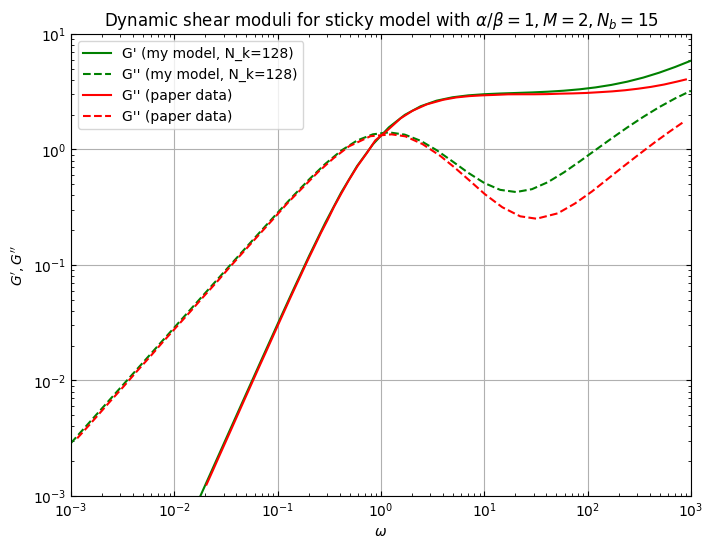

In [61]:
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(8,6))
plt.loglog(omegas, G_p_list, color='g', label=f"G' (my model, N_k=128)")
plt.loglog(omegas, G_pp_list, color='g', linestyle='--', label="G'' (my model, N_k=128)")
# plt.loglog(my_sticky_model_moduli_alpha_1["omega"], my_sticky_model_moduli_alpha_1["G'"], color='b', label=f"G' (my model, k_b=1)")
# plt.loglog(my_sticky_model_moduli_alpha_1["omega"], my_sticky_model_moduli_alpha_1["G''"], color='b', linestyle='--', label="G'' (my model, k_b=1)")
plt.loglog(paper_sticky_model_G_p_alpha_1["omega"], paper_sticky_model_G_p_alpha_1["G'"], color='r', label="G'' (paper data)")
plt.loglog(paper_sticky_model_G_pp_alpha_1["omega"], paper_sticky_model_G_pp_alpha_1["G''"], color='r', linestyle='--', label="G'' (paper data)")
plt.title(r"Dynamic shear moduli for sticky model with $\alpha/\beta=1, M=2, N_b=15$")
plt.xlabel(r"$\omega$")
plt.ylabel(r"$G', G''$")
plt.xlim(1e-3, 1e3)
plt.ylim(1e-3, 1e1)
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True)
plt.legend()
plt.grid()  
plt.show()